# Laboratorio ENEIC Notebook 02: Exploración, correlaciones y segmentación

Este notebook cubre los **puntos 2, 3 y 4** del laboratorio. Lee exclusivamente el Parquet de 2025 generado por `01_carga_calidad.ipynb`.

* Todas las estadísticas, correlaciones y métricas de clustering se calculan en Spark sobre el conjunto completo de 2025.
* A pandas solo se transfieren tablas agregadas o muestras de hasta 5,000 registros, y únicamente para dibujar.
* Los resultados son no ponderados: describen los registros analizados, no la población guatemalteca.
* Las asociaciones que se describen no implican causalidad.

## 0. Preparación

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pyspark
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.stat import Correlation

spark = (
    SparkSession.builder
    .appName("Lab ENEIC - 02 EDA y segmentacion")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)

BASE_DIR = Path(os.environ.get("LAB_BASE_DIR", "/opt/app"))
OUT_DIR  = BASE_DIR / "working_dir" / "eneic_parquet"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
SEED = 42
MAX_MUESTRA = 5000
fmt_q = mtick.FuncFormatter(lambda x, _: f"Q{x:,.0f}")

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/25 04:24:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/25 04:24:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark: 3.5.1


In [3]:
df = spark.read.parquet(str(OUT_DIR / "eneic_2025_preparado.parquet")).cache()
N = df.count()
print(f"Registros de la población analítica 2025: {N:,}")
df.groupBy("periodo_archivo").count().orderBy("periodo_archivo").show()
df.printSchema()

Registros de la población analítica 2025: 53,025
+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|13419|
|         2025T2|13492|
|         2025T3|13450|
|         2025T4|12664|
+---------------+-----+

root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- nivel_educativo_desc: string (nullable = tr

In [4]:
# Orden y etiquetas cortas para las gráficas
ORDEN_EDU = ["0", "1", "2", "3", "4", "5", "6", "7", "DESCONOCIDO"]
ORDEN_CAT = ["1", "2", "3", "4", "DESCONOCIDO"]
ORDEN_DOM = ["1", "2", "3", "DESCONOCIDO"]
CORTO_CAT = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero/peón", "4": "Servicio doméstico"}

def muestra(d, n=MAX_MUESTRA, cols=None):
    # Muestra aleatoria de hasta n registros, solo para graficar.
    total = d.count()
    frac = min(1.0, 1.2 * n / total)
    s = d.sample(False, frac, seed=SEED)
    if cols:
        s = s.select(*cols)
    return s.limit(n).toPandas()

## 2. Estadística descriptiva y preguntas de exploración

### 2.1 Resumen de las variables numéricas

Los percentiles se calculan con la función exacta `percentile` de Spark SQL, sobre los registros de 2025.

In [5]:
VARS_NUM = {
    "salario_mensual": "Salario mensual (Q)",
    "edad": "Edad (años)",
    "antiguedad": "Antigüedad (años)",
    "horas_semanales": "Horas habituales / semana",
}

def resumen_numerico(d, columnas):
    aggs = []
    for c in columnas:
        aggs += [
            F.count(c).alias(f"{c}|n"),
            F.mean(c).alias(f"{c}|media"),
            F.stddev(c).alias(f"{c}|desv_est"),
            F.min(c).alias(f"{c}|min"),
            F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias(f"{c}|pcts"),
            F.max(c).alias(f"{c}|max"),
            F.skewness(c).alias(f"{c}|asimetria"),
        ]
    fila = d.agg(*aggs).collect()[0].asDict()
    out = {}
    for c in columnas:
        p25, p50, p75, p95 = fila[f"{c}|pcts"]
        out[c] = {
            "n": fila[f"{c}|n"], "media": fila[f"{c}|media"], "mediana": p50,
            "desv_est": fila[f"{c}|desv_est"], "min": fila[f"{c}|min"], "p25": p25,
            "p75": p75, "p95": p95, "max": fila[f"{c}|max"], "asimetria": fila[f"{c}|asimetria"],
        }
    return pd.DataFrame(out).T

desc = resumen_numerico(df, list(VARS_NUM))
desc.index = [VARS_NUM[c] for c in desc.index]
desc["n"] = desc["n"].astype(int)
display(desc.round(2))

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
Salario mensual (Q),53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
Edad (años),53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
Antigüedad (años),53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
Horas habituales / semana,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


**Interpretación.**

* **Salario mensual.** La mitad de los asalariados registra Q3,000 o menos y el 50 % central está entre Q1,800 y Q4,000. La media (Q3,422) es mayor que la mediana, la desviación estándar (Q2,902) es casi tan grande como la media y el rango va de Q1 a Q99,000. El p95 es Q8,000, pero el máximo es más de 12 veces ese valor. El coeficiente de asimetría de 6.0 indica una cola derecha muy larga.
* **Edad.** Va de 15 a 89 años, con media de 35 y mediana de 33 años. La mitad central tiene entre 24 y 44 años: la población asalariada es predominantemente joven, con una asimetría positiva leve (0.7).
* **Antigüedad.** Es la variable más concentrada en valores bajos: la mediana es de solo **2 años**, mientras que la media es de 5.6 años. Un 25 % lleva medio año o menos en su empleo actual, y el 5 % supera los 22 años. Es una distribución asimétrica (2.4): muchos empleos recientes y pocos muy prolongados.
* **Horas habituales.** La mediana es de 45 horas semanales y el 50 % central trabaja entre 40 y 55 horas. Una cuarta parte trabaja 55 horas o más, y el 5 % trabaja 80 o más. En el otro extremo hay jornadas muy cortas (mínimo 1 hora), que corresponden a trabajos parciales u ocasionales.

### 2.2 ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?

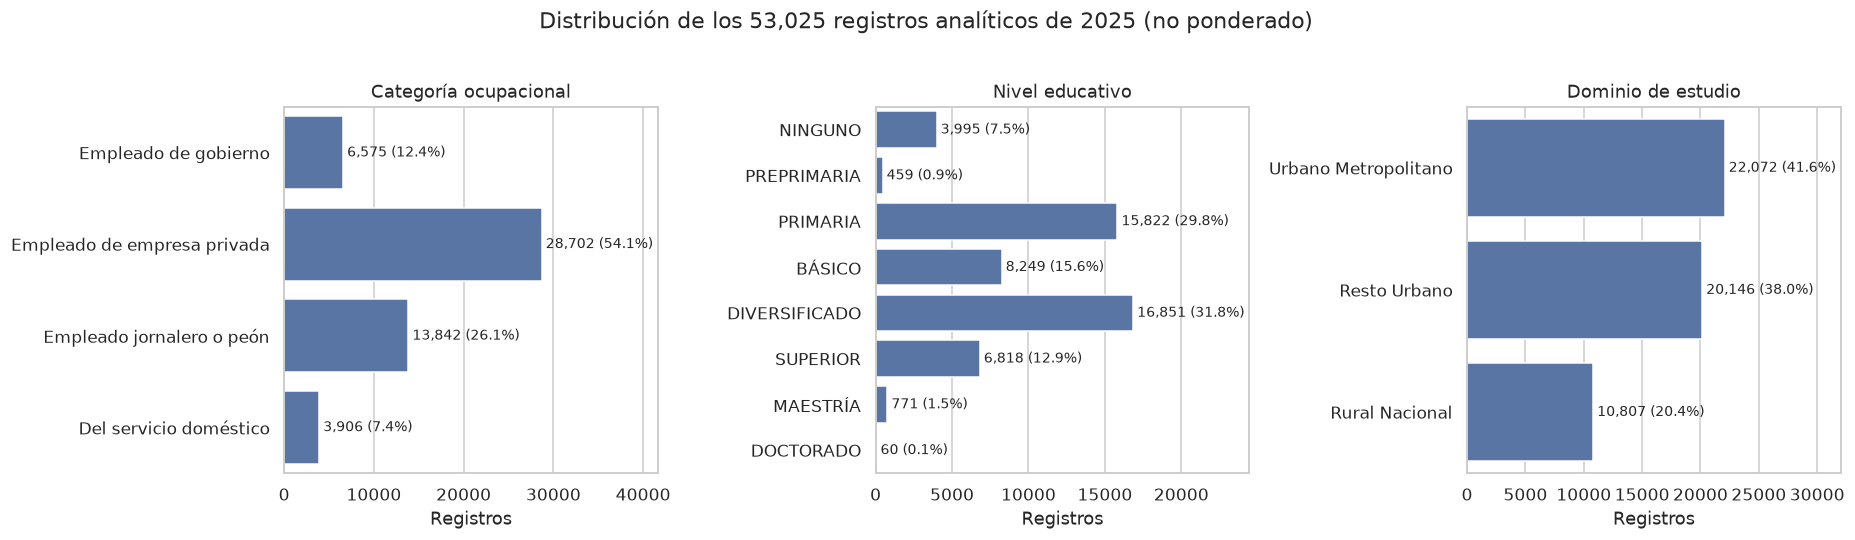

count    pct
Categoría Empleado de gobierno          6575  12.40
          Empleado de empresa privada  28702  54.13
          Empleado jornalero o peón    13842  26.10
          Del servicio doméstico        3906   7.37
Educación NINGUNO                       3995   7.53
          PREPRIMARIA                    459   0.87
          PRIMARIA                     15822  29.84
          BÁSICO                        8249  15.56
          DIVERSIFICADO                16851  31.78
          SUPERIOR                      6818  12.86
          MAESTRÍA                       771   1.45
          DOCTORADO                       60   0.11
Dominio   Urbano Metropolitano         22072  41.63
          Resto Urbano                 20146  37.99
          Rural Nacional               10807  20.38

In [6]:
def conteo(d, col, desc_col, orden):
    t = (d.groupBy(col, desc_col).count().toPandas())
    t["pct"] = 100 * t["count"] / t["count"].sum()
    t["orden"] = t[col].map({v: i for i, v in enumerate(orden)})
    return t.sort_values("orden").reset_index(drop=True)

t_cat = conteo(df, "categoria_ocupacional", "categoria_ocupacional_desc", ORDEN_CAT)
t_edu = conteo(df, "nivel_educativo", "nivel_educativo_desc", ORDEN_EDU)
t_dom = conteo(df, "dominio", "dominio_desc", ORDEN_DOM)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, t, col, titulo in [
    (axes[0], t_cat, "categoria_ocupacional_desc", "Categoría ocupacional"),
    (axes[1], t_edu, "nivel_educativo_desc", "Nivel educativo"),
    (axes[2], t_dom, "dominio_desc", "Dominio de estudio"),
]:
    sns.barplot(data=t, y=col, x="count", ax=ax, color="#4C72B0", orient="h")
    for i, (n, p) in enumerate(zip(t["count"], t["pct"])):
        ax.text(n, i, f" {n:,} ({p:.1f}%)", va="center", fontsize=9)
    ax.set_title(titulo); ax.set_ylabel(""); ax.set_xlabel("Registros")
    ax.set_xlim(0, t["count"].max() * 1.45)
fig.suptitle(f"Distribución de los {N:,} registros analíticos de 2025 (no ponderado)", y=1.02)
plt.tight_layout(); plt.show()

display(pd.concat({"Categoría": t_cat.set_index("categoria_ocupacional_desc")[["count", "pct"]],
                   "Educación": t_edu.set_index("nivel_educativo_desc")[["count", "pct"]],
                   "Dominio": t_dom.set_index("dominio_desc")[["count", "pct"]]}).round(2))

**Interpretación.** Los registros no se reparten de manera uniforme:

* **Categoría ocupacional:** más de la mitad son empleados de **empresa privada** (54 %), seguidos de **jornaleros o peones** (26 %), empleados de **gobierno** (12 %) y **servicio doméstico** (7 %).
* **Nivel educativo:** dos niveles concentran el 62 % de los registros: **diversificado** (32 %) y **primaria** (30 %). Un 8 % no tiene ningún nivel aprobado y un 13 % tiene educación superior. **Maestría** (771) y **doctorado** (60) son grupos muy pequeños, por lo que cualquier estadística sobre ellos es más inestable.
* **Dominio:** 42 % urbano metropolitano, 38 % resto urbano y 20 % rural.

Estos porcentajes son conteos **no ponderados** de la muestra. Reflejan tanto la estructura del empleo asalariado como el diseño muestral, así que no deben leerse como la composición de los asalariados del país. Para eso habría que ponderar por `FACTOR`.

### 2.3 ¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe entre su media y su mediana?

El histograma se construye en Spark y solo la tabla de frecuencias se lleva a pandas. Se muestra en escala lineal (recortada en Q20,000 para que se vea la forma; los valores superiores se indican aparte) y en **escala logarítmica base 10** en el eje X. La escala log es solo para visualizar: el modelado usa el salario original en quetzales.

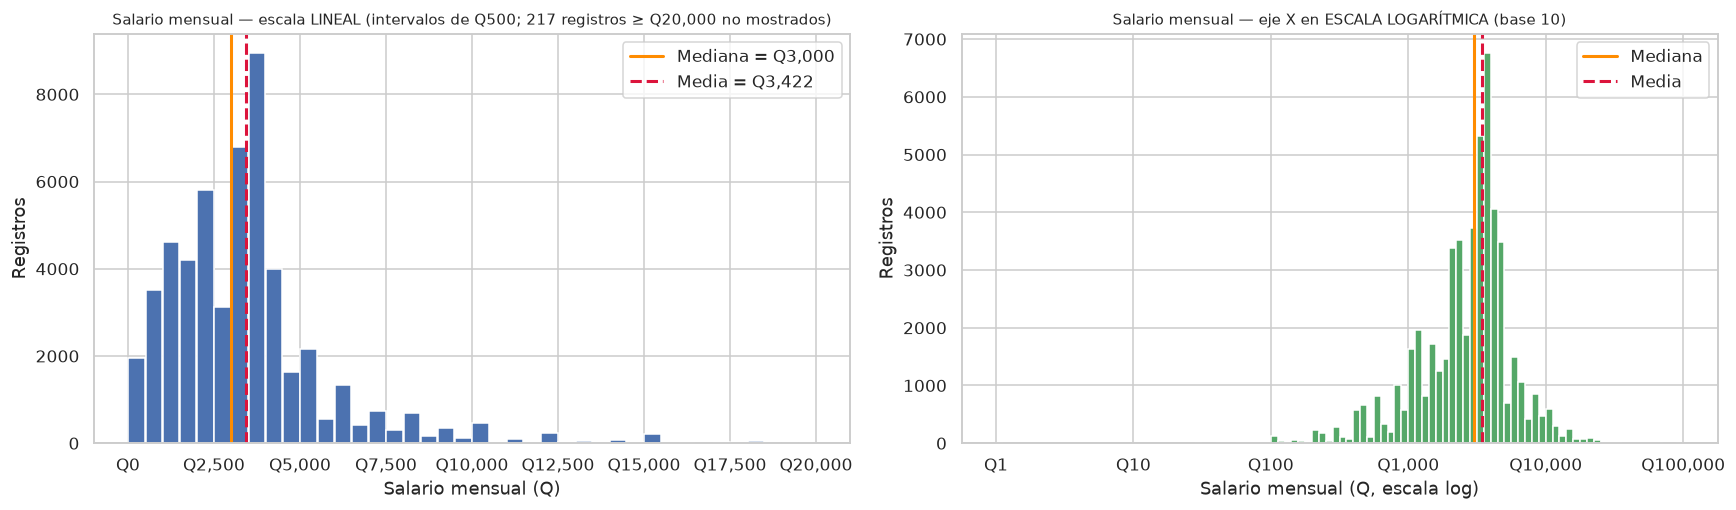

Media - mediana = Q421.68  (media/mediana = 1.141)
Coeficiente de asimetría (skewness) = 6.00


In [7]:
st = desc.loc["Salario mensual (Q)"]
media_sal, mediana_sal = st["media"], st["mediana"]

ANCHO, TOPE = 500, 20000
h_lin = (df.select(F.when(F.col("salario_mensual") >= TOPE, F.lit(TOPE))
                    .otherwise(F.floor(F.col("salario_mensual") / ANCHO) * ANCHO).alias("bin"))
           .groupBy("bin").count().orderBy("bin").toPandas())
sobre_tope = int(h_lin.loc[h_lin["bin"] == TOPE, "count"].sum())
h_lin = h_lin[h_lin["bin"] < TOPE]

ANCHO_LOG = 0.05
h_log = (df.select((F.floor(F.log10("salario_mensual") / ANCHO_LOG) * ANCHO_LOG).alias("bin"))
           .groupBy("bin").count().orderBy("bin").toPandas())

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
ax = axes[0]
ax.bar(h_lin["bin"] + ANCHO / 2, h_lin["count"], width=ANCHO * 0.95, color="#4C72B0")
ax.axvline(mediana_sal, color="darkorange", lw=2, label=f"Mediana = Q{mediana_sal:,.0f}")
ax.axvline(media_sal, color="crimson", lw=2, ls="--", label=f"Media = Q{media_sal:,.0f}")
ax.xaxis.set_major_formatter(fmt_q)
ax.set_title(f"Salario mensual — escala LINEAL (intervalos de Q{ANCHO}; {sobre_tope:,} registros ≥ Q{TOPE:,} no mostrados)", fontsize=10)
ax.set_xlabel("Salario mensual (Q)"); ax.set_ylabel("Registros"); ax.legend()

ax = axes[1]
ax.bar(10 ** (h_log["bin"] + ANCHO_LOG / 2), h_log["count"],
       width=10 ** (h_log["bin"] + ANCHO_LOG) - 10 ** h_log["bin"], color="#55A868", align="center")
ax.set_xscale("log")
ax.axvline(mediana_sal, color="darkorange", lw=2, label="Mediana")
ax.axvline(media_sal, color="crimson", lw=2, ls="--", label="Media")
ax.xaxis.set_major_formatter(fmt_q)
ax.set_title("Salario mensual — eje X en ESCALA LOGARÍTMICA (base 10)", fontsize=10)
ax.set_xlabel("Salario mensual (Q, escala log)"); ax.set_ylabel("Registros"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Media - mediana = Q{media_sal - mediana_sal:,.2f}  (media/mediana = {media_sal / mediana_sal:.3f})")
print(f"Coeficiente de asimetría (skewness) = {st['asimetria']:.2f}")

In [8]:
# Peso de los valores extremos en la media
cortes = df.select(
    F.count("*").alias("n"),
    F.sum((F.col("salario_mensual") > st["p95"]).cast("int")).alias("n_sobre_p95"),
    F.sum(F.when(F.col("salario_mensual") > st["p95"], F.col("salario_mensual"))).alias("masa_sobre_p95"),
    F.sum("salario_mensual").alias("masa_total"),
    F.sum((F.col("salario_mensual") >= 30000).cast("int")).alias("n_30k_o_mas"),
    F.mean(F.when(F.col("salario_mensual") <= st["p95"], F.col("salario_mensual"))).alias("media_hasta_p95"),
).collect()[0]
print(f"Registros por encima del p95 (Q{st['p95']:,.0f}): {cortes.n_sobre_p95:,} "
      f"({100 * cortes.n_sobre_p95 / cortes.n:.1f}% de los registros), "
      f"concentran el {100 * cortes.masa_sobre_p95 / cortes.masa_total:.1f}% de la suma de salarios")
print(f"Registros con salario ≥ Q30,000: {cortes.n_30k_o_mas}")
print(f"Media calculada solo hasta el p95 (ilustrativo, NO se recorta el objetivo): Q{cortes.media_hasta_p95:,.0f}")

print("\nDiez salarios más altos y más bajos (para discutir extremos):")
cols_ext = ["periodo_archivo", "salario_mensual", "edad", "antiguedad", "horas_semanales",
            "nivel_educativo_desc", "categoria_ocupacional_desc", "dominio_desc"]
df.orderBy(F.desc("salario_mensual")).select(*cols_ext).show(10, truncate=False)
df.orderBy("salario_mensual").select(*cols_ext).show(10, truncate=False)

Registros por encima del p95 (Q8,000): 2,341 (4.4% de los registros), concentran el 16.5% de la suma de salarios
Registros con salario ≥ Q30,000: 60
Media calculada solo hasta el p95 (ilustrativo, NO se recorta el objetivo): Q2,991

Diez salarios más altos y más bajos (para discutir extremos):
+---------------+---------------+----+------------------+---------------+--------------------+---------------------------+--------------------+
|periodo_archivo|salario_mensual|edad|antiguedad        |horas_semanales|nivel_educativo_desc|categoria_ocupacional_desc |dominio_desc        |
+---------------+---------------+----+------------------+---------------+--------------------+---------------------------+--------------------+
|2025T3         |99000.0        |64.0|3.0               |44.0           |SUPERIOR            |Empleado de empresa privada|Urbano Metropolitano|
|2025T1         |99000.0        |63.0|3.0               |54.0           |SUPERIOR            |Empleado de empresa privada|Urbano 

**Interpretación.**

* **¿Simétrica o asimétrica?** Claramente asimétrica a la derecha (asimetría = 6.0). En escala lineal, la mayoría de registros se concentra por debajo de Q5,000 y hay una cola larga de salarios altos; 217 registros tienen Q20,000 o más y ni siquiera caben en el gráfico. En escala logarítmica la distribución se ve mucho más compacta y cercana a una campana, lo que indica que el salario se comporta aproximadamente de forma log-normal. Ambos histogramas muestran picos en valores redondos, típicos de salarios declarados por los encuestados. También hay una concentración marcada entre Q3,500 y Q4,000, rango que posiblemente se asocia al salario mínimo vigente.
* **Diferencia entre media y mediana.** La media (Q3,422) supera a la mediana (Q3,000) en Q422, es decir, un 14.1 %. La diferencia se debe a la cola derecha: el 4.4 % de registros por encima del p95 (Q8,000) concentra el 16.5 % de la suma de todos los salarios. Solo como ilustración, si se calculara la media hasta el p95, bajaría a Q2,991, por debajo de la mediana. Para describir el salario “típico” es más representativa la mediana.
* **Influencia de los extremos.** Los tres valores máximos (Q99,000) pertenecen a una persona de 63–64 años con educación superior, empleada en empresa privada metropolitana, observada en I, II y III de 2025 con el mismo hogar y número de persona. Es probablemente la misma persona en tres trimestres (panel rotativo). Puede ser un salario real de un puesto directivo, pero también un valor de relleno tipo “99…”; como el diccionario no lo define como código especial, se conserva. En el otro extremo, el mínimo es un registro de III de 2025 con Q1 al mes y 50 horas semanales, lo cual no es coherente con la jornada y probablemente es un error de captura; se conserva porque cumple el criterio de salario positivo, pero es un caso a vigilar. Después vienen salarios de Q30 a Q50, siempre asociados a jornadas de 1 a 6 horas semanales, lo cual sí es coherente con trabajos ocasionales. En el modelado, estos extremos pueden influir mucho en métricas cuadráticas como el RMSE; su efecto se discutirá en esa etapa, sin eliminarlos de la evaluación principal.

### 2.4 ¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?

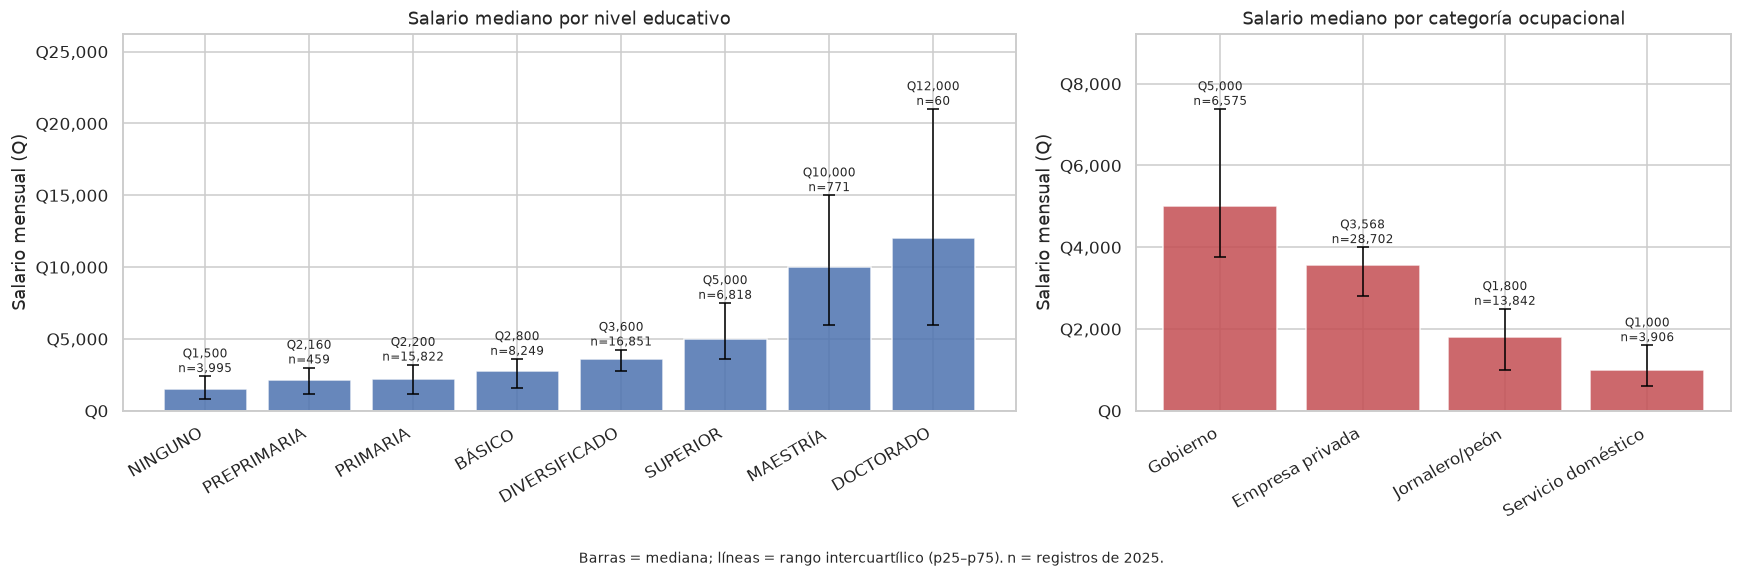

,nivel_educativo,nivel_educativo_desc,n,mediana,p25,p75,media
0,0,NINGUNO,3995,1500.0,800.0,2400.0,1767.0
1,1,PREPRIMARIA,459,2160.0,1200.0,3000.0,2242.0
2,2,PRIMARIA,15822,2200.0,1200.0,3200.0,2308.0
3,3,BÁSICO,8249,2800.0,1600.0,3600.0,2730.0
4,4,DIVERSIFICADO,16851,3600.0,2800.0,4250.0,3796.0
5,5,SUPERIOR,6818,5000.0,3600.0,7500.0,5965.0
6,6,MAESTRÍA,771,10000.0,6000.0,15000.0,11409.0
7,7,DOCTORADO,60,12000.0,6000.0,21000.0,14452.0


,categoria_ocupacional,categoria_ocupacional_desc,n,mediana,p25,p75,media
0,1,Empleado de gobierno,6575,5000.0,3750.0,7380.0,5972.0
1,2,Empleado de empresa privada,28702,3568.0,2800.0,4000.0,3875.0
2,3,Empleado jornalero o peón,13842,1800.0,1000.0,2490.0,1879.0
3,4,Del servicio doméstico,3906,1000.0,600.0,1600.0,1266.0


In [9]:
def salario_por(d, cols):
    return (d.groupBy(*cols)
             .agg(F.count("*").alias("n"),
                  F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                  F.expr("percentile(salario_mensual, 0.25)").alias("p25"),
                  F.expr("percentile(salario_mensual, 0.75)").alias("p75"),
                  F.mean("salario_mensual").alias("media"))
             .toPandas())

s_edu = salario_por(df, ["nivel_educativo", "nivel_educativo_desc"])
s_edu = s_edu.set_index("nivel_educativo").reindex([c for c in ORDEN_EDU if c in set(s_edu.nivel_educativo)]).reset_index()
s_cat = salario_por(df, ["categoria_ocupacional", "categoria_ocupacional_desc"])
s_cat = s_cat.set_index("categoria_ocupacional").reindex([c for c in ORDEN_CAT if c in set(s_cat.categoria_ocupacional)]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.5, 1]})
for ax, t, col, titulo, color in [
    (axes[0], s_edu, "nivel_educativo_desc", "Salario mediano por nivel educativo", "#4C72B0"),
    (axes[1], s_cat, "categoria_ocupacional_desc", "Salario mediano por categoría ocupacional", "#C44E52"),
]:
    x = np.arange(len(t))
    ax.bar(x, t["mediana"], color=color, alpha=0.85)
    ax.errorbar(x, t["mediana"], yerr=[t["mediana"] - t["p25"], t["p75"] - t["mediana"]],
                fmt="none", ecolor="black", capsize=4, lw=1)
    for i, r in t.iterrows():
        ax.text(i, r["p75"], f"Q{r['mediana']:,.0f}\nn={r['n']:,}", ha="center", va="bottom", fontsize=8)
    etq = t.iloc[:, 0].map(CORTO_CAT).fillna(t[col]) if col.startswith("categoria") else t[col]
    ax.set_xticks(x); ax.set_xticklabels(etq, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(fmt_q); ax.set_title(titulo); ax.set_ylabel("Salario mensual (Q)")
    ax.set_ylim(0, t["p75"].max() * 1.25)
fig.text(0.5, -0.04, "Barras = mediana; líneas = rango intercuartílico (p25–p75). n = registros de 2025.", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

display(s_edu.round(0)); display(s_cat.round(0))

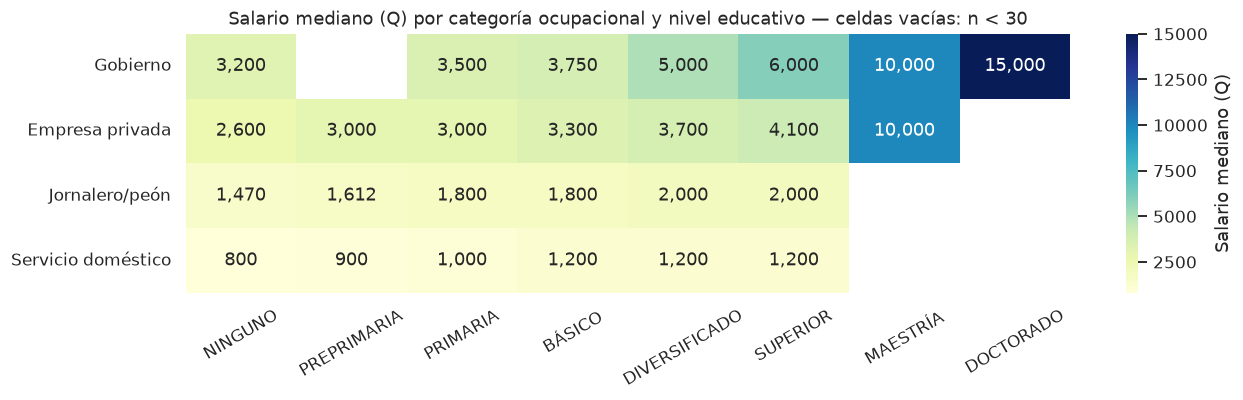

In [10]:
# Cruce: mediana por categoría y nivel educativo (celdas con menos de 30 registros se ocultan)
cruce = salario_por(df, ["categoria_ocupacional", "nivel_educativo"])
cruce["cat"] = cruce["categoria_ocupacional"].map(CORTO_CAT)
cruce["edu"] = cruce["nivel_educativo"].map(dict(zip(s_edu.nivel_educativo, s_edu.nivel_educativo_desc)))
piv_med = cruce.pivot(index="cat", columns="edu", values="mediana")
piv_n = cruce.pivot(index="cat", columns="edu", values="n")
orden_cols = [e for e in s_edu.nivel_educativo_desc if e in piv_med.columns]
piv_med, piv_n = piv_med[orden_cols].loc[list(CORTO_CAT.values())], piv_n[orden_cols].loc[list(CORTO_CAT.values())]

fig, ax = plt.subplots(figsize=(12, 3.8))
sns.heatmap(piv_med.where(piv_n >= 30), annot=True, fmt=",.0f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "Salario mediano (Q)"}, mask=(piv_n < 30) | piv_n.isna())
ax.set_title("Salario mediano (Q) por categoría ocupacional y nivel educativo — celdas vacías: n < 30")
ax.set_xlabel(""); ax.set_ylabel(""); ax.grid(False); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Interpretación.**

* **Nivel educativo.** El salario mediano aumenta de forma monótona con la educación: Q1,500 sin nivel aprobado, Q2,200 con primaria, Q2,800 con básico, Q3,600 con diversificado, Q5,000 con superior y Q10,000 con maestría. El salto más grande ocurre entre superior y posgrado. La mediana de doctorado (Q12,000) se basa en solo 60 registros y tiene un rango intercuartílico muy amplio, así que debe tomarse con cautela. La dispersión también crece en los niveles altos: el rango intercuartílico pasa de unos Q1,500–2,000 hasta diversificado a Q3,900 en superior y Q9,000 en maestría.
* **Categoría ocupacional.** El gobierno tiene la mediana más alta (Q5,000), seguido de la empresa privada (Q3,568); los jornaleros o peones (Q1,800) y el servicio doméstico (Q1,000) están muy por debajo. La mediana del servicio doméstico es la quinta parte de la del gobierno.
* **Cruce de ambas variables.** El mapa de calor muestra que las dos variables se relacionan entre sí, pero cada una aporta información propia. Dentro de cada categoría el salario sube con la educación, pero mucho más en gobierno (de Q3,200 a Q6,000 con superior) que en jornaleros (de Q1,470 a Q2,000) o servicio doméstico (de Q800 a Q1,200). Además, a igual nivel educativo la categoría marca diferencias grandes: con diversificado, la mediana va de Q1,200 en servicio doméstico a Q5,000 en gobierno. Parte de la diferencia entre categorías se explica porque tienen composiciones educativas distintas, pero no toda.

Son asociaciones descriptivas: no indican que la educación cause un salario determinado, pues intervienen otros factores no observados (ocupación específica, sector, región, experiencia total).

### 2.5 ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?

,periodo_archivo,n,mediana,p25,p75,media
0,2025T1,13419,3000.0,1600.0,3960.0,3316.0
1,2025T2,13492,3000.0,1680.0,4000.0,3365.0
2,2025T3,13450,3200.0,1800.0,4000.0,3469.0
3,2025T4,12664,3200.0,2000.0,4000.0,3545.0


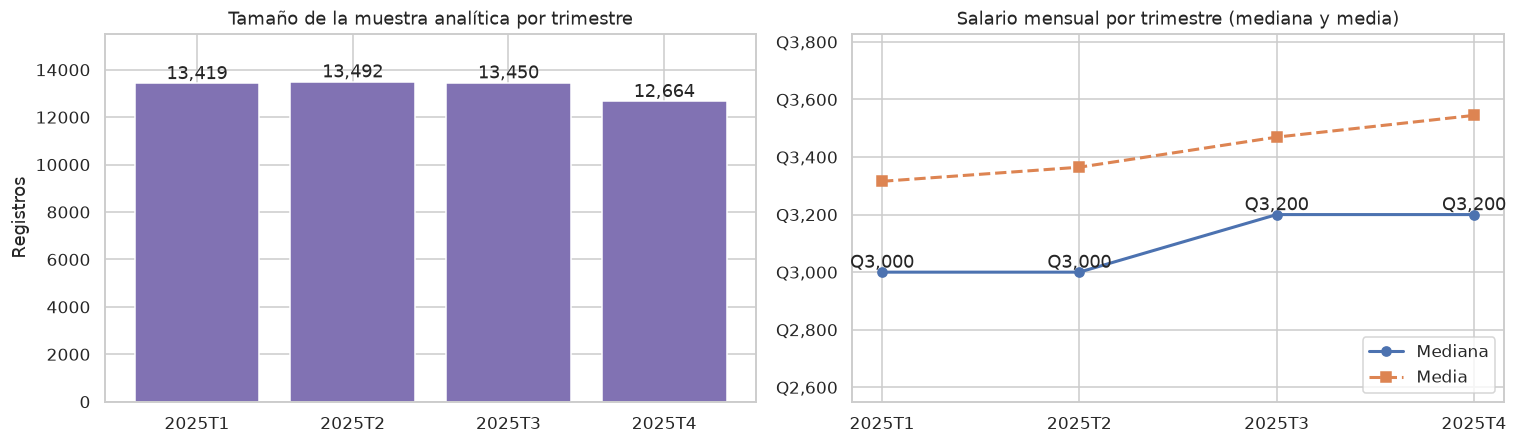

categoria_ocupacional_desc,Del servicio doméstico,Empleado de empresa privada,Empleado de gobierno,Empleado jornalero o peón
periodo_archivo,,,,
2025T1,6.8,50.9,12.1,30.2
2025T2,7.6,52.9,12.1,27.4
2025T3,7.4,56.3,12.5,23.9
2025T4,7.7,56.7,12.9,22.7


In [11]:
s_tri = salario_por(df, ["periodo_archivo"]).sort_values("periodo_archivo").reset_index(drop=True)
display(s_tri.round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(s_tri["periodo_archivo"], s_tri["n"], color="#8172B3")
for i, n in enumerate(s_tri["n"]):
    axes[0].text(i, n, f"{n:,}", ha="center", va="bottom")
axes[0].set_title("Tamaño de la muestra analítica por trimestre"); axes[0].set_ylabel("Registros")
axes[0].set_ylim(0, s_tri["n"].max() * 1.15)

axes[1].plot(s_tri["periodo_archivo"], s_tri["mediana"], marker="o", lw=2, label="Mediana")
axes[1].plot(s_tri["periodo_archivo"], s_tri["media"], marker="s", lw=2, ls="--", label="Media")
for i, m in enumerate(s_tri["mediana"]):
    axes[1].text(i, m, f"Q{m:,.0f}", ha="center", va="bottom")
axes[1].yaxis.set_major_formatter(fmt_q); axes[1].set_title("Salario mensual por trimestre (mediana y media)")
axes[1].set_ylim(s_tri["mediana"].min() * 0.85, s_tri["media"].max() * 1.08); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

# Composición por trimestre: ¿cambió la mezcla de categorías?
comp = (df.groupBy("periodo_archivo", "categoria_ocupacional_desc").count()
          .toPandas().pivot(index="periodo_archivo", columns="categoria_ocupacional_desc", values="count"))
display((100 * comp.div(comp.sum(axis=1), axis=0)).round(1))

**Interpretación.**

* **Tamaño de la muestra.** El número de asalariados con salario positivo es estable entre trimestres (entre 12,664 y 13,492 registros); IV de 2025 es algo menor. En todos los casos representa cerca del 26 % de los registros de cada archivo, así que ningún trimestre domina la unión.
* **Salario mediano.** Se mantiene en Q3,000 en I y II de 2025 y sube a Q3,200 en III y IV de 2025. La media sigue el mismo patrón y crece en cada trimestre.
* **Posible explicación: composición.** La tabla de composición muestra que la proporción de jornaleros o peones cae de 30 % a 23 %, mientras que la de empresa privada sube de 51 % a 57 %. Esto sugiere un patrón estacional del empleo agrícola. Por lo tanto, el aumento de la mediana en III y IV no implica necesariamente que los salarios individuales hayan subido: puede deberse a que cambió la mezcla de trabajadores observados. Las diferencias son pequeñas y los datos no ponderados no permiten afirmar que sean cambios poblacionales.

## 3. Relaciones entre variables numéricas

Se usa `VectorAssembler` para construir el vector de las cuatro variables y `Correlation.corr()` de `pyspark.ml.stat` para la matriz de Pearson sobre todos los registros elegibles de 2025. Como complemento se calcula Spearman, menos sensible a la asimetría y a los valores extremos del salario.

Matriz de correlación de Pearson (n = 53,025):


,Salario,Edad,Antigüedad,Horas
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas,0.076,-0.105,-0.062,1.000


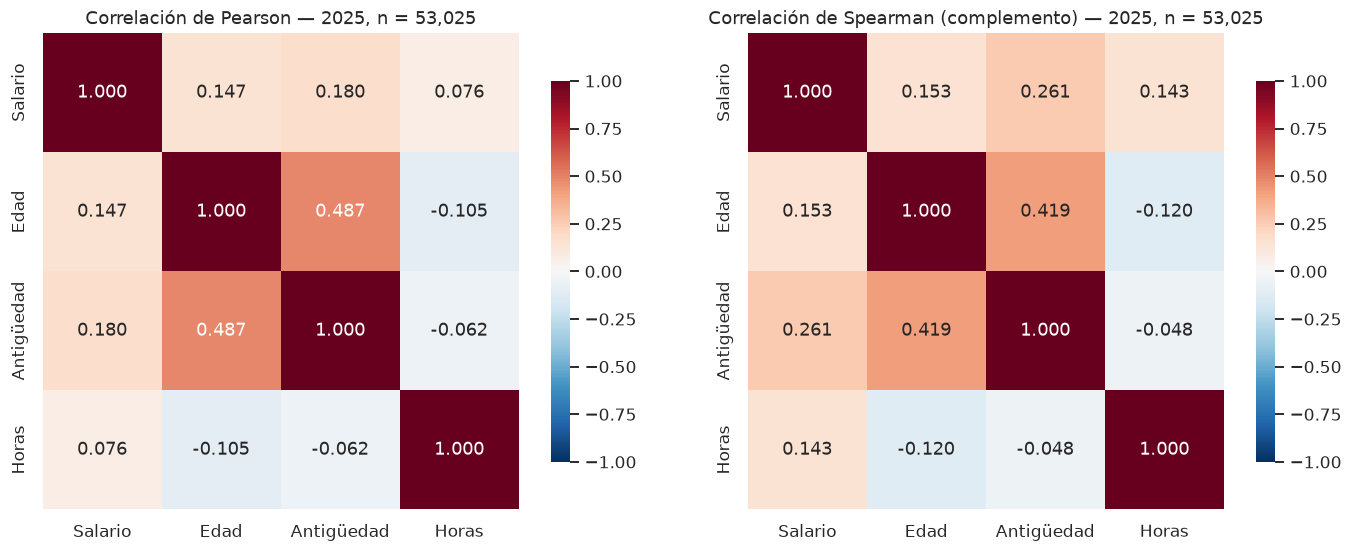

In [12]:
VARS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQ_CORR = ["Salario", "Edad", "Antigüedad", "Horas"]

vec = VectorAssembler(inputCols=VARS_CORR, outputCol="features").transform(df).select("features")
pearson = Correlation.corr(vec, "features", "pearson").head()[0].toArray()
spearman = Correlation.corr(vec, "features", "spearman").head()[0].toArray()

m_pearson = pd.DataFrame(pearson, index=ETIQ_CORR, columns=ETIQ_CORR)
m_spearman = pd.DataFrame(spearman, index=ETIQ_CORR, columns=ETIQ_CORR)
print(f"Matriz de correlación de Pearson (n = {N:,}):")
display(m_pearson.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m, t in [(axes[0], m_pearson, "Pearson"), (axes[1], m_spearman, "Spearman (complemento)")]:
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"Correlación de {t} — 2025, n = {N:,}")
plt.tight_layout(); plt.show()

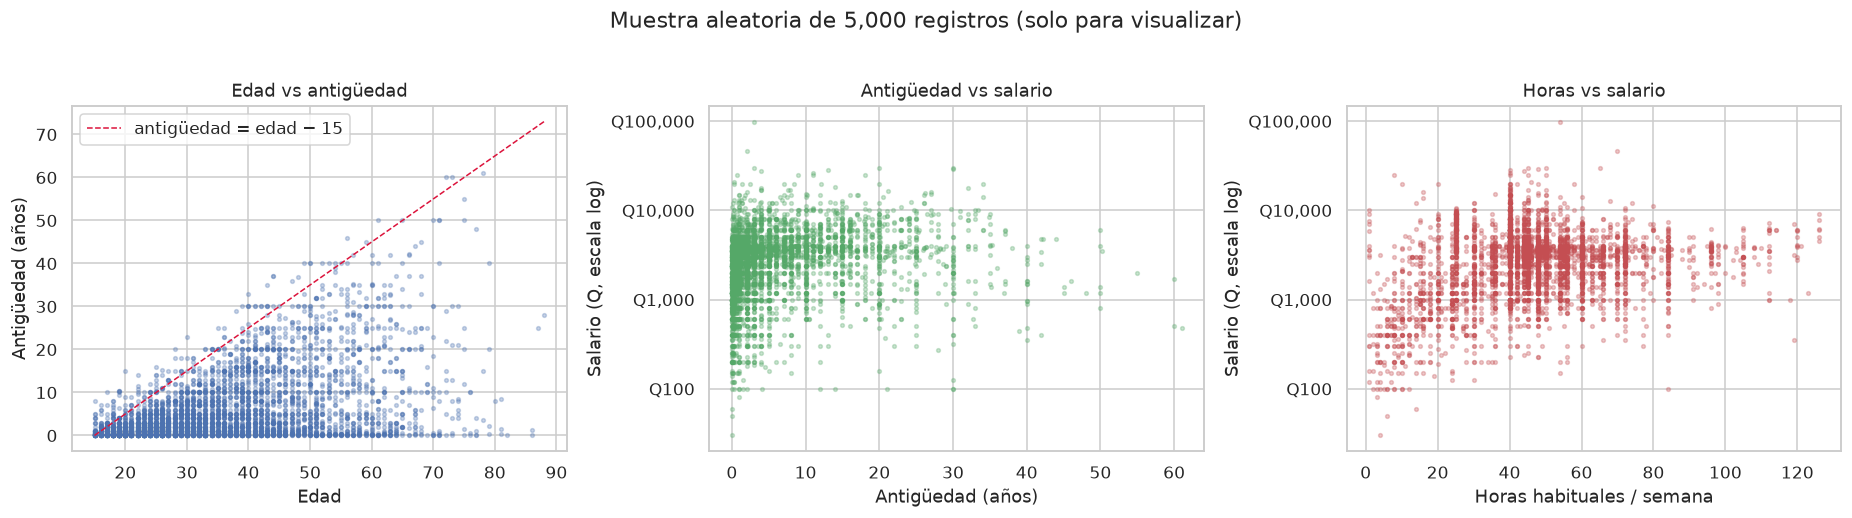

In [13]:
# Visualización de apoyo (muestra de hasta 5,000 registros; las correlaciones ya se calcularon con todos)
sm = muestra(df, cols=VARS_CORR + ["categoria_ocupacional"])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].scatter(sm["edad"], sm["antiguedad"], s=6, alpha=0.3)
x = np.linspace(15, sm["edad"].max(), 50)
axes[0].plot(x, x - 15, color="crimson", lw=1, ls="--", label="antigüedad = edad − 15")
axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Antigüedad (años)"); axes[0].legend(); axes[0].set_title("Edad vs antigüedad")
axes[1].scatter(sm["antiguedad"], sm["salario_mensual"], s=6, alpha=0.3, color="#55A868")
axes[1].set_yscale("log"); axes[1].yaxis.set_major_formatter(fmt_q)
axes[1].set_xlabel("Antigüedad (años)"); axes[1].set_ylabel("Salario (Q, escala log)"); axes[1].set_title("Antigüedad vs salario")
axes[2].scatter(sm["horas_semanales"], sm["salario_mensual"], s=6, alpha=0.3, color="#C44E52")
axes[2].set_yscale("log"); axes[2].yaxis.set_major_formatter(fmt_q)
axes[2].set_xlabel("Horas habituales / semana"); axes[2].set_ylabel("Salario (Q, escala log)"); axes[2].set_title("Horas vs salario")
fig.suptitle(f"Muestra aleatoria de {len(sm):,} registros (solo para visualizar)", y=1.02)
plt.tight_layout(); plt.show()

**Interpretación.**

* **¿Qué variables presentan mayor asociación lineal con el salario?** Todas las correlaciones de Pearson con el salario son **positivas pero débiles**. La más alta es con la **antigüedad** (r = 0.18), seguida de la **edad** (r = 0.15); con las **horas** es casi nula (r = 0.08). Ninguna variable numérica explica por sí sola una parte importante de la variación salarial: el cuadrado de la correlación con la antigüedad es apenas 0.03, es decir, alrededor de 3 % de la varianza. Con Spearman, las asociaciones son algo mayores (antigüedad 0.26, horas 0.14), lo que indica que la relación existe, pero no es lineal y queda diluida por la asimetría y los salarios extremos. Esto anticipa que, para estimar el salario, las variables categóricas (educación y categoría ocupacional, que en la sección 2.4 muestran diferencias muy grandes) serán más informativas que las numéricas.
* **¿Existe relación entre edad y antigüedad?** Sí: es la correlación más fuerte de la matriz (r = 0.49, positiva y moderada). Las personas mayores tienden a llevar más tiempo en su empleo, y el gráfico de dispersión muestra el límite natural de que la antigüedad no puede superar la edad menos la edad de inicio laboral. La relación no es más fuerte porque la antigüedad mide el tiempo en el **empleo actual**, no la experiencia total: hay muchas personas mayores con poca antigüedad (cambiaron de empleo recientemente), como se ve en la franja inferior del gráfico. La correlación moderada implica cierta redundancia entre ambas variables, algo relevante para interpretar coeficientes en un modelo lineal.
* Las **horas** tienen una relación ligeramente negativa con la edad (r = −0.10): los más jóvenes tienden a trabajar jornadas algo más largas.

## 4. Segmentación de perfiles mediante KMeans

### 4.1 Selección de variables

**Variables de la segmentación principal:** `edad`, `antiguedad` y `horas_semanales`. Describen la etapa de vida laboral y la intensidad de la jornada, y permiten responder “¿qué perfiles de trabajadores asalariados existen?” sin usar el resultado económico.

**¿Vale la pena incluir el salario?** Se evalúa como variante (en logaritmo, porque en quetzales su asimetría haría que unos pocos salarios altos dominen las distancias). Las razones para **no** incluirlo en la segmentación principal son:

1. **Circularidad:** la segunda pregunta del laboratorio es qué tan bien se estima el salario. Si los perfiles se construyen con el salario, sus diferencias salariales son “por construcción” y no un hallazgo.
2. **Uso posterior:** perfiles basados en características observables pueden describirse (y asignarse) para cualquier persona, aunque no se conozca su salario.
3. **Dominancia de escala:** incluso estandarizado, el salario tiene colas largas que desplazan los centroides.

Las variables categóricas (educación, categoría, dominio) no entran en KMeans —la distancia euclidiana no es adecuada para códigos nominales—, pero se usan para **describir** los clusters.

### 4.2 Estandarización y elección de K

Cada configuración es un `Pipeline` de `VectorAssembler` → `StandardScaler(withMean=True, withStd=True)` → `KMeans`. Para K = 2, 3, 4 y 5 se calculan:

* **Silueta** (`ClusteringEvaluator`, distancia euclidiana al cuadrado) sobre **todos** los registros: mide qué tan separados están los grupos (−1 a 1; más alto es mejor).
* **WSSSE** (suma de cuadrados dentro de los clusters, `trainingCost`) para el método del codo.
* **Tamaño del cluster más pequeño**, para evitar grupos marginales poco útiles.

In [14]:
df_km = df.withColumn("log_salario", F.log10("salario_mensual")).cache()

CONFIGS = {
    "A: edad + antigüedad + horas": ["edad", "antiguedad", "horas_semanales"],
    "B: A + log10(salario)": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
evaluador = ClusteringEvaluator(featuresCol="features_std", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

def ajustar(columnas, k, seed=SEED, datos=df_km):
    pipe = Pipeline(stages=[
        VectorAssembler(inputCols=columnas, outputCol="features_raw"),
        StandardScaler(inputCol="features_raw", outputCol="features_std", withMean=True, withStd=True),
        KMeans(featuresCol="features_std", predictionCol="cluster", k=k, seed=seed, maxIter=50),
    ])
    modelo = pipe.fit(datos)
    pred = modelo.transform(datos)
    return modelo, pred

resultados = []
for nombre, columnas in CONFIGS.items():
    for k in [2, 3, 4, 5]:
        modelo, pred = ajustar(columnas, k)
        tam = pred.groupBy("cluster").count().toPandas()["count"]
        resultados.append({
            "configuracion": nombre, "k": k,
            "silueta": evaluador.evaluate(pred),
            "wssse": modelo.stages[-1].summary.trainingCost,
            "cluster_min_pct": 100 * tam.min() / N,
        })
res_k = pd.DataFrame(resultados)
display(res_k.round(4))

,configuracion,k,silueta,wssse,cluster_min_pct
0,A: edad + antigüedad + horas,2,0.5547,106717.3861,27.5078
1,A: edad + antigüedad + horas,3,0.4429,84468.1462,13.5351
2,A: edad + antigüedad + horas,4,0.4747,64437.0334,12.9109
3,A: edad + antigüedad + horas,5,0.4912,56848.4469,4.9316
4,B: A + log10(salario),2,0.4112,171215.4850,22.9439
5,B: A + log10(salario),3,0.4753,125145.1728,17.6049
6,B: A + log10(salario),4,0.3722,107227.4645,11.5398
7,B: A + log10(salario),5,0.3868,91789.2670,10.5912


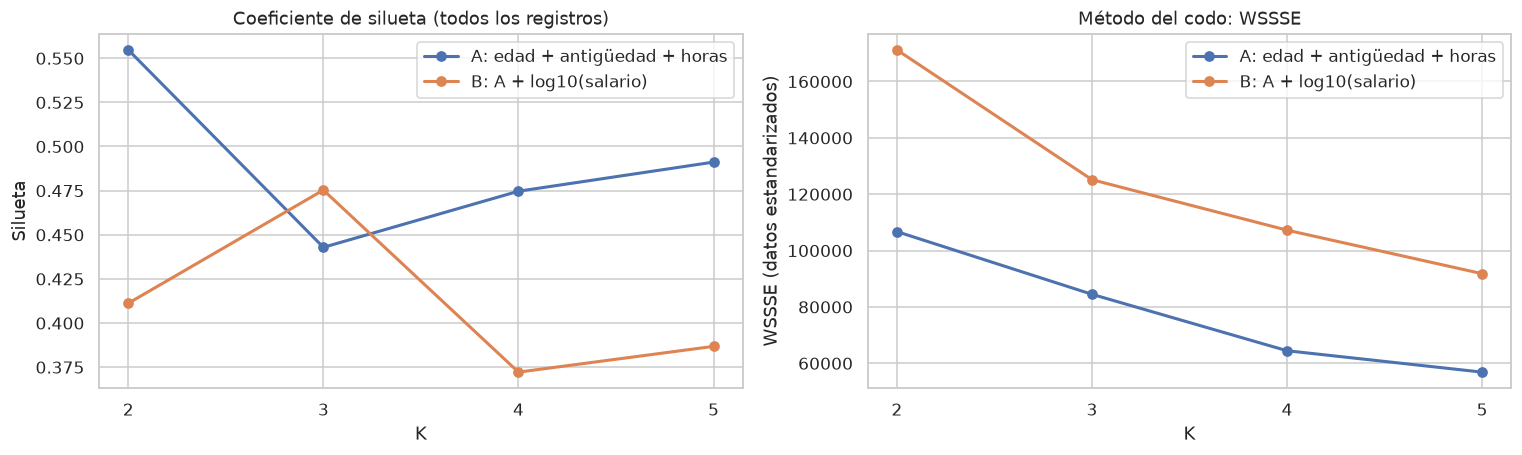

Reducción % del WSSSE (config. A): {3: np.float64(20.8), 4: np.float64(23.7), 5: np.float64(11.8)}


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for nombre, g in res_k.groupby("configuracion"):
    axes[0].plot(g["k"], g["silueta"], marker="o", lw=2, label=nombre)
    axes[1].plot(g["k"], g["wssse"], marker="o", lw=2, label=nombre)
axes[0].set_title("Coeficiente de silueta (todos los registros)"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Silueta")
axes[1].set_title("Método del codo: WSSSE"); axes[1].set_xlabel("K"); axes[1].set_ylabel("WSSSE (datos estandarizados)")
for ax in axes:
    ax.set_xticks([2, 3, 4, 5]); ax.legend()
plt.tight_layout(); plt.show()

# Reducción relativa del WSSSE al pasar de K-1 a K (configuración A)
gA = res_k[res_k.configuracion.str.startswith("A")].set_index("k")
print("Reducción % del WSSSE (config. A):", {k: round(100 * (1 - gA.wssse[k] / gA.wssse[k - 1]), 1) for k in [3, 4, 5]})

In [16]:
# Robustez: ¿la silueta depende de la semilla de inicialización? (configuración A)
rob = []
for k in [2, 3, 4, 5]:
    for s in [1, 7, 42, 2024]:
        _, p = ajustar(CONFIGS["A: edad + antigüedad + horas"], k, seed=s)
        rob.append({"k": k, "seed": s, "silueta": evaluador.evaluate(p)})
rob = pd.DataFrame(rob)
display(rob.pivot(index="k", columns="seed", values="silueta").round(4))

seed,1,7,42,2024
k,,,,
2,0.5547,0.5547,0.5547,0.5547
3,0.4429,0.4429,0.4429,0.4716
4,0.4325,0.4747,0.4747,0.4753
5,0.4425,0.4422,0.4912,0.4912


**Elección de K.** El criterio del grupo combina tres señales y exige que el resultado sea interpretable:

| K | Silueta (A) | Reducción del WSSSE | Cluster más pequeño | Estabilidad entre semillas |
|---|---|---|---|---|
| 2 | **0.555** | — | 27.5 % | estable |
| 3 | 0.443 | 20.8 % | 13.5 % | **inestable** (0.443–0.472) |
| 4 | 0.475 | **23.7 %** | 12.9 % | estable en 3 de 4 semillas (0.475; 0.433 con semilla 1) |
| 5 | 0.491 | 11.8 % | 4.9 % | **variable** (0.442–0.491) |

* **K = 2** tiene la silueta más alta, pero solo separa a los trabajadores mayores y con más antigüedad (mediana de 51 años de edad y 13 de antigüedad) del resto. Es una partición demasiado gruesa para responder qué **perfiles** existen.
* **K = 3** tiene la silueta más baja, y además su valor cambia según la semilla: KMeans llega a soluciones distintas, lo que muestra que no hay una estructura clara de tres grupos.
* **K = 4** marca el **codo**: pasar de 3 a 4 grupos todavía reduce el WSSSE un 24 %, pero pasar de 4 a 5 solo un 12 %. Su silueta (0.47) indica una estructura razonable; con tres de las cuatro semillas se obtiene la misma solución (0.475), y solo la semilla 1 cae en un óptimo local peor (0.433). Todos los grupos tienen cerca del 13 % de los registros o más.
* **K = 5** mejora apenas la silueta, pero agrega un grupo de menos del 5 % y es menos estable (solo dos de las cuatro semillas alcanzan 0.491).

**Se elige K = 4** con la configuración A (sin salario): es el mejor equilibrio entre separación, estabilidad, tamaño de los grupos e interpretabilidad.

In [17]:
CONFIG_ELEGIDA = "A: edad + antigüedad + horas"
K_ELEGIDO = 4

modelo_final, pred_final = ajustar(CONFIGS[CONFIG_ELEGIDA], K_ELEGIDO)
pred_final = pred_final.cache()
print(f"Configuración: {CONFIG_ELEGIDA} | K = {K_ELEGIDO} | silueta = {evaluador.evaluate(pred_final):.4f}")

Configuración: A: edad + antigüedad + horas | K = 4 | silueta = 0.4747


### 4.3 Perfil de cada cluster

Para describir los grupos se calculan, **sobre todos los registros**, el tamaño, las medias y medianas de las variables de segmentación, el salario (que no participó en la segmentación) y la composición por categoría, educación y dominio. Los centroides también se expresan en **unidades estandarizadas** (z): valores positivos indican que el grupo está por encima del promedio general.

In [18]:
VARS_SEG = CONFIGS[CONFIG_ELEGIDA]

perfil = (pred_final.groupBy("cluster").agg(
    F.count("*").alias("n"),
    *[F.mean(c).alias(f"media_{c}") for c in VARS_SEG],
    *[F.expr(f"percentile({c}, 0.5)").alias(f"mediana_{c}") for c in VARS_SEG],
    F.expr("percentile(salario_mensual, 0.5)").alias("mediana_salario"),
    F.mean("salario_mensual").alias("media_salario"),
    F.mean((F.col("nivel_educativo").isin("5", "6", "7")).cast("int")).alias("pct_superior_o_mas"),
    F.mean((F.col("nivel_educativo").isin("0", "1", "2")).cast("int")).alias("pct_primaria_o_menos"),
    F.mean((F.col("dominio") == "1").cast("int")).alias("pct_metropolitano"),
    F.mean((F.col("dominio") == "3").cast("int")).alias("pct_rural"),
).toPandas().sort_values("cluster").set_index("cluster"))
perfil["pct_registros"] = 100 * perfil["n"] / N
for c in ["pct_superior_o_mas", "pct_primaria_o_menos", "pct_metropolitano", "pct_rural"]:
    perfil[c] = 100 * perfil[c]

# Centroides estandarizados (z) respecto a la media y desviación general
gen = df.select(*[F.mean(c).alias(f"m_{c}") for c in VARS_SEG], *[F.stddev(c).alias(f"s_{c}") for c in VARS_SEG]).collect()[0]
z = pd.DataFrame({c: (perfil[f"media_{c}"] - gen[f"m_{c}"]) / gen[f"s_{c}"] for c in VARS_SEG})
display(perfil.round(2).T)

cluster,0,1,2,3
n,12524.00,24400.00,6846.00,9255.00
media_edad,48.80,26.00,49.87,30.13
media_antiguedad,4.09,2.44,22.27,3.41
media_horas_semanales,39.73,40.59,41.04,74.17
mediana_edad,47.00,26.00,48.00,29.00
mediana_antiguedad,3.00,1.25,20.00,2.00
mediana_horas_semanales,42.00,44.00,40.00,72.00
mediana_salario,3000.00,3000.00,3800.00,3000.00
media_salario,3537.78,3083.16,4683.35,3223.81
pct_superior_o_mas,15.81,14.15,24.63,5.73


,z_edad,z_antiguedad,z_horas_semanales,n,pct_registros,mediana_salario,descripcion_auto
cluster,,,,,,,
0,1.01,-0.19,-0.35,12524,23.6,3000.0,mayores
1,-0.68,-0.40,-0.31,24400,46.0,3000.0,jóvenes
2,1.09,2.13,-0.28,6846,12.9,3800.0,"mayores, con alta antigüedad"
3,-0.37,-0.27,1.50,9255,17.5,3000.0,con jornada larga


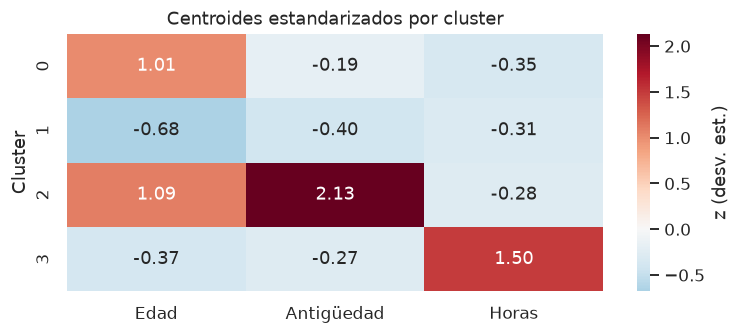

In [19]:
# Descripción automática a partir de los centroides estandarizados
NOMBRES_VAR = {"edad": ("jóvenes", "mayores"), "antiguedad": ("con poca antigüedad", "con alta antigüedad"),
               "horas_semanales": ("con jornada corta", "con jornada larga"), "log_salario": ("de salario bajo", "de salario alto")}

def describir(fila, umbral=0.5):
    partes = []
    for c in VARS_SEG:
        if fila[c] <= -umbral:
            partes.append(NOMBRES_VAR[c][0])
        elif fila[c] >= umbral:
            partes.append(NOMBRES_VAR[c][1])
    return ", ".join(partes) if partes else "cercano al promedio general"

perfil["descripcion_auto"] = z.apply(describir, axis=1)
display(pd.concat([z.round(2).add_prefix("z_"), perfil[["n", "pct_registros", "mediana_salario", "descripcion_auto"]].round(1)], axis=1))

fig, ax = plt.subplots(figsize=(7, 0.8 + 0.6 * K_ELEGIDO))
sns.heatmap(z.rename(columns={"edad": "Edad", "antiguedad": "Antigüedad", "horas_semanales": "Horas"}),
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "z (desv. est.)"})
ax.set_title("Centroides estandarizados por cluster"); ax.set_ylabel("Cluster")
plt.tight_layout(); plt.show()

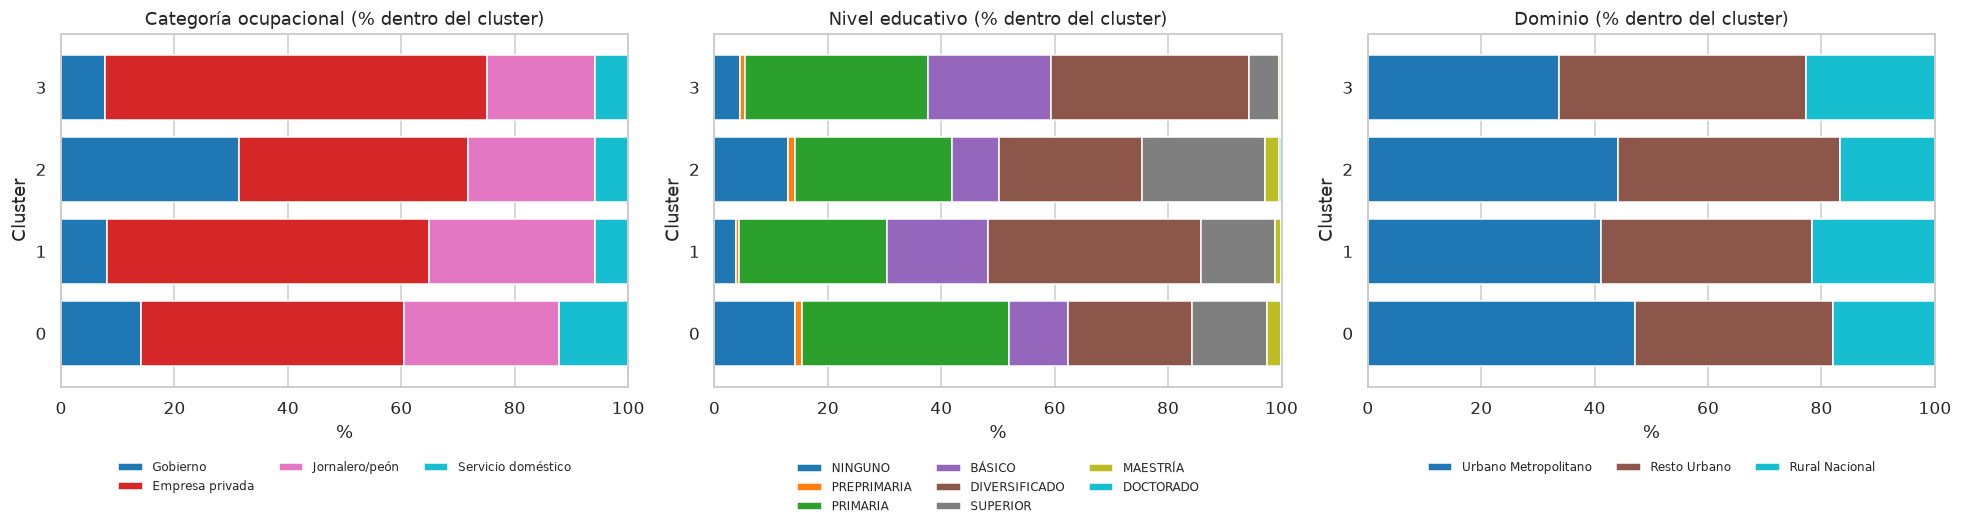

categoria_ocupacional,Gobierno,Empresa privada,Jornalero/peón,Servicio doméstico
cluster,,,,
0,14.0,46.5,27.3,12.2
1,8.0,56.8,29.2,5.9
2,31.4,40.4,22.4,5.9
3,7.7,67.4,19.0,5.8


nivel_educativo_desc,NINGUNO,PREPRIMARIA,PRIMARIA,BÁSICO,DIVERSIFICADO,SUPERIOR,MAESTRÍA,DOCTORADO
cluster,,,,,,,,
0,14.2,1.2,36.6,10.5,21.8,13.2,2.5,0.2
1,3.7,0.6,26.0,17.9,37.6,13.1,1.0,0.0
2,13.0,1.1,27.8,8.3,25.1,21.7,2.4,0.5
3,4.4,0.9,32.3,21.7,34.9,5.3,0.4,0.0


In [20]:
# Composición de cada cluster por categoría ocupacional y nivel educativo (% dentro del cluster)
def composicion(col, etiquetas=None):
    t = pred_final.groupBy("cluster", col).count().toPandas().pivot(index="cluster", columns=col, values="count").fillna(0)
    t = 100 * t.div(t.sum(axis=1), axis=0)
    return t.rename(columns=etiquetas) if etiquetas else t

comp_cat = composicion("categoria_ocupacional", CORTO_CAT)
comp_edu = composicion("nivel_educativo_desc")[[e for e in s_edu.nivel_educativo_desc if e in composicion("nivel_educativo_desc").columns]]
comp_dom = composicion("dominio_desc")[[d for d in ["Urbano Metropolitano", "Resto Urbano", "Rural Nacional"] if d in composicion("dominio_desc").columns]]

fig, axes = plt.subplots(1, 3, figsize=(18, 0.9 + 0.55 * K_ELEGIDO + 2))
for ax, t, titulo in [(axes[0], comp_cat, "Categoría ocupacional"), (axes[1], comp_edu, "Nivel educativo"), (axes[2], comp_dom, "Dominio")]:
    t.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", width=0.8, legend=False)
    ax.set_title(f"{titulo} (% dentro del cluster)"); ax.set_xlabel("%"); ax.set_ylabel("Cluster"); ax.set_xlim(0, 100)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
display(comp_cat.round(1)); display(comp_edu.round(1))

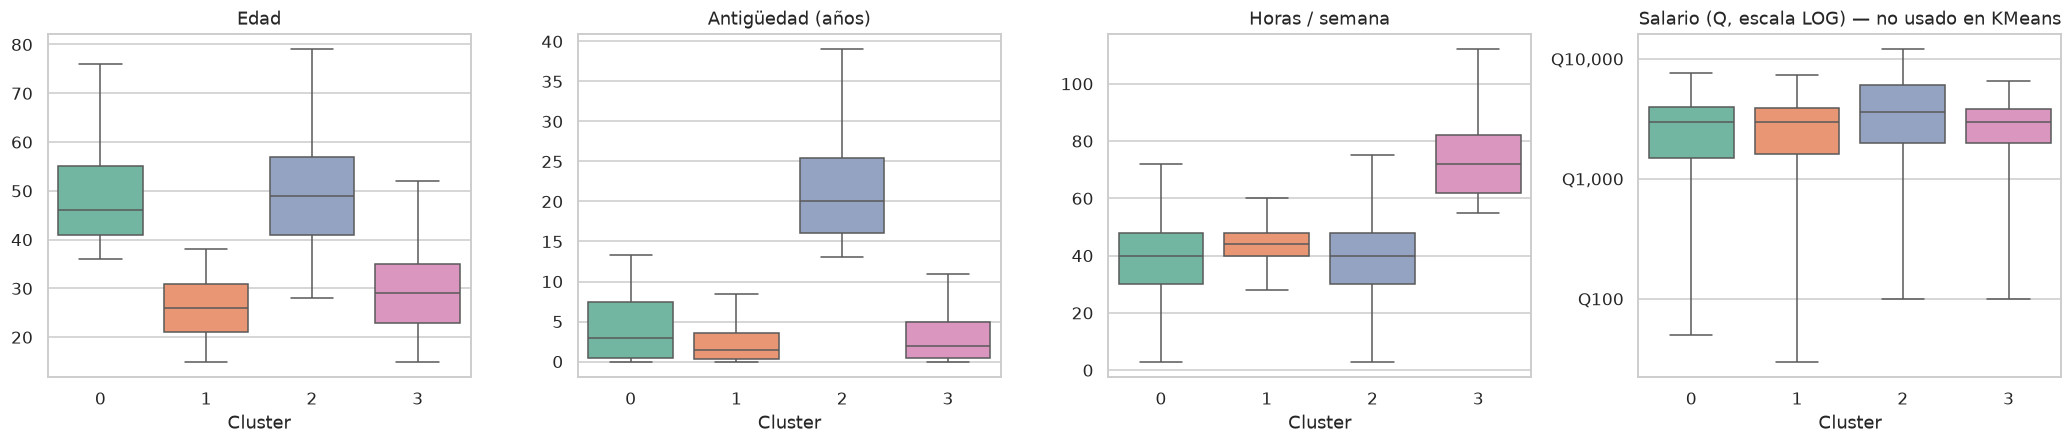

Varianza explicada por los 2 componentes: [0.505 0.325]


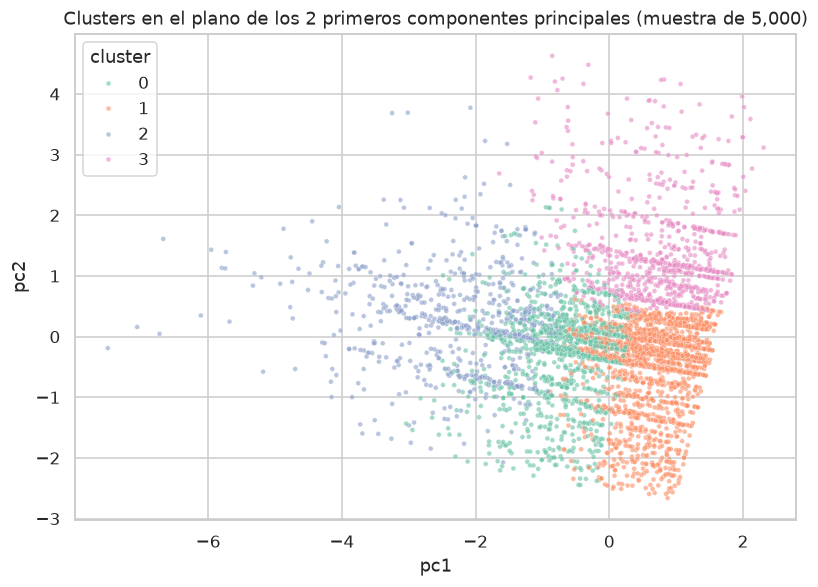

In [21]:
# Distribuciones por cluster (muestra de hasta 5,000 registros, solo para visualizar)
spc = muestra(pred_final, cols=VARS_SEG + ["salario_mensual", "cluster"])
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, c, t in zip(axes, ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
                    ["Edad", "Antigüedad (años)", "Horas / semana", "Salario (Q, escala LOG) — no usado en KMeans"]):
    sns.boxplot(data=spc, x="cluster", y=c, hue="cluster", ax=ax, showfliers=False, palette="Set2", legend=False)
    ax.set_title(t); ax.set_xlabel("Cluster"); ax.set_ylabel("")
axes[3].set_yscale("log"); axes[3].yaxis.set_major_formatter(fmt_q)
plt.tight_layout(); plt.show()

# Proyección PCA (ajustada con todos los registros; se dibuja una muestra)
pca = PCA(k=2, inputCol="features_std", outputCol="pca").fit(pred_final)
print("Varianza explicada por los 2 componentes:", np.round(pca.explainedVariance.toArray(), 3))
pp = pca.transform(pred_final).select("cluster", "pca")
pp = pp.sample(False, min(1.0, 1.2 * MAX_MUESTRA / N), seed=SEED).limit(MAX_MUESTRA).toPandas()
pp[["pc1", "pc2"]] = np.vstack(pp["pca"].map(lambda v: v.toArray()))
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=pp, x="pc1", y="pc2", hue="cluster", palette="Set2", s=10, alpha=0.6, ax=ax)
ax.set_title(f"Clusters en el plano de los 2 primeros componentes principales (muestra de {len(pp):,})")
plt.tight_layout(); plt.show()

**Descripción de los clusters (K = 4, configuración A).** Los números de cluster corresponden a esta ejecución; la columna `descripcion_auto` y los centroides permiten reconocer cada perfil aunque la numeración cambie.

| Cluster | % | Perfil | Rasgos principales |
|---|---|---|---|
| **1** | 46 % | **Jóvenes en inicio de trayectoria** | Edad mediana 26 años, antigüedad mediana 1.3 años, jornada estándar (44 h). Es el grupo más numeroso. Predomina la empresa privada (57 %) y el nivel diversificado (38 %). Salario mediano Q3,000. |
| **0** | 24 % | **Adultos con empleo reciente** | Edad mediana 47 años, pero antigüedad de solo 3 años, y jornada algo menor al promedio (mediana 42 h, media 40 h). Tienen el mayor porcentaje con primaria o menos (52 %) y la mayor presencia de servicio doméstico (12 %). Salario mediano Q3,000. Son personas maduras que cambiaron o iniciaron empleo recientemente. |
| **3** | 17 % | **Jornadas extensas** | Horas medianas de **72 por semana** (z = +1.5), edad mediana 29 años, antigüedad baja. Dos terceras partes trabajan en empresa privada (67 %); predominan básico y diversificado, con solo 5.7 % de educación superior. Salario mediano Q3,000, igual al de grupos que trabajan unas 30 horas menos, lo que implica una remuneración por hora considerablemente más baja. |
| **2** | 13 % | **Trabajadores de carrera larga** | Edad mediana 48 años y antigüedad mediana de **20 años** (z = +2.1), jornada estándar (40 h). Tiene la mayor proporción de empleados de gobierno (31 %) y de educación superior o más (25 %). Es el único grupo con salario mediano claramente mayor (Q3,800). |

**Lectura conjunta.** La segmentación separa cuatro situaciones laborales: la **etapa de entrada** (jóvenes con poca antigüedad), la **estabilidad** (carrera larga, frecuentemente en el sector público), la **rotación en la adultez** (personas maduras con empleos recientes) y la **sobrecarga de jornada**. Aunque el salario no se usó para formar los grupos, solo el perfil de carrera larga se distingue en salario mediano. Esto es coherente con las correlaciones débiles de la sección 3: edad, antigüedad y horas describen bien **cómo** trabaja la gente, pero por sí solas dicen poco sobre **cuánto** gana. El boxplot de salario (escala log) muestra que las distribuciones salariales de los cuatro grupos se traslapan ampliamente.

La proyección PCA (los dos componentes explican el 83 % de la varianza estandarizada) muestra grupos contiguos, sin fronteras nítidas: los perfiles son **regiones** de un continuo más que poblaciones separadas, lo cual es consistente con una silueta moderada (0.47).

### 4.4 ¿Qué cambia si se incluye el salario?

In [22]:
modelo_B, pred_B = ajustar(CONFIGS["B: A + log10(salario)"], K_ELEGIDO)
print(f"Silueta con salario (B, K={K_ELEGIDO}): {evaluador.evaluate(pred_B):.4f}  vs  sin salario (A): {evaluador.evaluate(pred_final):.4f}")

perfil_B = (pred_B.groupBy("cluster").agg(
    F.count("*").alias("n"), F.mean("edad").alias("media_edad"), F.mean("antiguedad").alias("media_antiguedad"),
    F.mean("horas_semanales").alias("media_horas"), F.expr("percentile(salario_mensual, 0.5)").alias("mediana_salario"),
    F.mean(F.col("categoria_ocupacional").isin("3", "4").cast("int") * 100).alias("pct_jornalero_domestico"),
).toPandas().sort_values("mediana_salario"))
display(perfil_B.round(1))

# ¿Cuánto se parecen las dos particiones? Tabla cruzada A vs B
cruce_AB = (pred_final.select("NUM_HOGAR", "NUM_PERSONA", "periodo_archivo", F.col("cluster").alias("cluster_A"))
            .join(pred_B.select("NUM_HOGAR", "NUM_PERSONA", "periodo_archivo", F.col("cluster").alias("cluster_B")),
                  ["NUM_HOGAR", "NUM_PERSONA", "periodo_archivo"])
            .groupBy("cluster_A").pivot("cluster_B").count().orderBy("cluster_A").toPandas().set_index("cluster_A").fillna(0))
print("Registros por cluster sin salario (filas) vs con salario (columnas):")
display(cruce_AB.astype(int))

Silueta con salario (B, K=4): 0.3722  vs  sin salario (A): 0.4747


,cluster,n,media_edad,media_antiguedad,media_horas,mediana_salario,pct_jornalero_domestico
0,3,7851,33.7,3.0,24.0,800.0,76.9
1,1,23979,25.6,2.3,54.9,3180.0,28.3
3,0,15076,44.8,5.0,45.7,3650.0,22.0
2,2,6119,51.2,23.1,42.9,3800.0,26.1


Registros por cluster sin salario (filas) vs con salario (columnas):


,0,1,2,3
cluster_A,,,,
0,9882,45,44,2553
1,3287,16185,0,4928
2,549,11,5950,336
3,1358,7738,125,34


**¿Vale la pena incluir el salario?** Con K = 4, agregar `log10(salario)` **reduce la silueta de 0.475 a 0.372**. Con salario, la mejor silueta es 0.475 con K = 3: prácticamente igual a la de A con K = 4 (0.475) e inferior a la mejor de A (0.555 con K = 2), así que incluir el salario no mejora la separación. La tabla cruzada muestra que la inclusión reorganiza los grupos alrededor del salario:

* Aparece un grupo de **salario bajo y jornada corta** (mediana Q800, 24 horas semanales), donde el 77 % son jornaleros o trabajadoras de servicio doméstico. Este grupo se forma sobre todo con registros de los perfiles “jóvenes” (4,928) y “adultos con empleo reciente” (2,553); casi no toma registros de “jornadas extensas” (34).
* Los perfiles “jóvenes” y “jornadas extensas”, bien diferenciados sin salario, se fusionan parcialmente.

Por lo tanto, la decisión es **no incluir el salario** en la segmentación principal. Con salario los grupos son menos compactos, y además quedan definidos por la variable que después se quiere estimar: sus diferencias salariales serían consecuencia de cómo se construyeron, no un hallazgo. El análisis con salario sí deja un resultado útil: existe un segmento de **baja remuneración asociado a jornadas cortas y a las categorías de jornalero y servicio doméstico**, que conviene tener presente al interpretar los errores de los modelos de regresión.

In [23]:
# Guardar asignaciones y perfiles para referencia (la etiqueta de cluster NO se usará como predictor)
(pred_final.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "cluster")
    .coalesce(1).write.mode("overwrite").parquet(str(OUT_DIR / "eneic_2025_clusters.parquet")))
perfil.to_csv(OUT_DIR / "perfiles_clusters_2025.csv")
res_k.to_csv(OUT_DIR / "seleccion_k_2025.csv", index=False)
print("Guardado en", OUT_DIR)

Guardado en /opt/app/working_dir/eneic_parquet


## Conclusiones de los puntos 2 a 4

1. **Salario.** Tiene una distribución fuertemente asimétrica a la derecha (media Q3,422 > mediana Q3,000), con valores redondos frecuentes y pocos salarios muy altos que pesan mucho en la media. La mediana es la medida de tendencia central más adecuada. Los extremos se conservan y su influencia se discutirá en el modelado.
2. **Diferencias entre grupos.** Las diferencias salariales más grandes aparecen entre **niveles educativos** (de Q1,500 sin educación a Q10,000 con maestría) y entre **categorías ocupacionales** (de Q1,000 en servicio doméstico a Q5,000 en gobierno), y ambas dimensiones aportan información propia.
3. **Variables numéricas.** Se asocian de forma débil con el salario (r ≤ 0.18). Edad y antigüedad están moderadamente correlacionadas (r = 0.49).
4. **Trimestres.** Muestra y salario mediano son estables. El leve aumento en III y IV de 2025 coincide con una menor proporción de jornaleros, por lo que puede reflejar un cambio de composición.
5. **Perfiles.** KMeans con K = 4 (edad, antigüedad y horas estandarizadas, sin salario) identifica jóvenes en inicio de trayectoria, adultos con empleo reciente, trabajadores con jornadas extensas y trabajadores de carrera larga. Solo este último grupo se distingue en salario mediano.

Todos los resultados son **no ponderados** y describen los registros analizados de asalariados con salario positivo; no son estimaciones oficiales de la población guatemalteca. Las asociaciones encontradas no son causales.

In [24]:
spark.catalog.clearCache()